# MinIO + Parquet + DuckDB Read Benchmark

Workflow:
1. Download the MinIO server binary and start it as a background process inside the devcontainer.
2. Generate 1 M synthetic 64×64 JPEG patches and write them to a Parquet file.
3. Upload the Parquet file to MinIO.
4. Use DuckDB (httpfs/S3 extension) to query a random batch of patches and time it.

## 0 — Start MinIO server

Downloads the `minio` binary to `/tmp` if absent, then starts it in the background.
Re-running this cell is safe — it detects an already-running server.

In [1]:
import os
import subprocess
import time
import urllib.request

MINIO_BIN  = '/tmp/minio'
MINIO_DATA = '/tmp/minio-data'
MINIO_PORT = 9000

# Download binary if missing
if not os.path.exists(MINIO_BIN):
    print('Downloading minio binary...')
    urllib.request.urlretrieve(
        'https://dl.min.io/server/minio/release/linux-amd64/minio',
        MINIO_BIN
    )
    os.chmod(MINIO_BIN, 0o755)
    print('Downloaded.')

os.makedirs(MINIO_DATA, exist_ok=True)

# Check if already running
check = subprocess.run(['pgrep', '-f', 'minio server'], capture_output=True)
if check.returncode == 0:
    print('MinIO already running.')
else:
    env = os.environ.copy()
    env['MINIO_ROOT_USER']     = 'minioadmin'
    env['MINIO_ROOT_PASSWORD'] = 'minioadmin'
    proc = subprocess.Popen(
        [MINIO_BIN, 'server', MINIO_DATA, '--address', f':{MINIO_PORT}'],
        env=env,
        stdout=subprocess.DEVNULL,
        stderr=subprocess.DEVNULL,
    )
    time.sleep(2)
    if proc.poll() is not None:
        raise RuntimeError(f'MinIO exited immediately (code {proc.returncode})')
    print(f'MinIO started (pid {proc.pid}) on port {MINIO_PORT}.')

MinIO started (pid 138090) on port 9000.


## 1 — Configuration

In [2]:
import io
import random
import time

import boto3
import duckdb
import numpy as np
import pyarrow as pa
import pyarrow.parquet as pq
from botocore.client import Config
from PIL import Image

MINIO_ENDPOINT = 'http://127.0.0.1:9000'
MINIO_ACCESS   = 'minioadmin'
MINIO_SECRET   = 'minioadmin'
BUCKET         = 'patches'
PARQUET_KEY    = 'bench_images.parquet'

TOTAL_IMAGES   = 1_000_000
IMAGE_SIZE     = (64, 64, 3)
WRITE_BATCH    = 50_000   # rows per PyArrow write batch (keeps RAM low)

N_READS        = 1_000    # random patches to fetch in the read benchmark

print('Config OK')

Config OK


## 2 — Generate Parquet file locally

Writes `TOTAL_IMAGES` rows in batches to `/tmp/bench_images.parquet`.  
Schema: `id INTEGER`, `image_data BINARY` (JPEG bytes).  
A single pre-generated JPEG is reused for all rows (mirrors `insert_test_3.py`).

In [3]:
LOCAL_PARQUET = '/tmp/bench_images.parquet'

def generate_jpeg_bytes():
    arr = np.random.randint(0, 256, IMAGE_SIZE, dtype=np.uint8)
    buf = io.BytesIO()
    Image.fromarray(arr).save(buf, format='JPEG', quality=85)
    return buf.getvalue()

schema = pa.schema([
    pa.field('id',         pa.int32()),
    pa.field('image_data', pa.large_binary()),
])

jpeg_bytes = generate_jpeg_bytes()  # reuse one image

t0 = time.perf_counter()
writer = pq.ParquetWriter(LOCAL_PARQUET, schema, compression='snappy')

for batch_start in range(0, TOTAL_IMAGES, WRITE_BATCH):
    batch_end = min(batch_start + WRITE_BATCH, TOTAL_IMAGES)
    n = batch_end - batch_start
    table = pa.table(
        {'id': list(range(batch_start, batch_end)), 'image_data': [jpeg_bytes] * n},
        schema=schema
    )
    writer.write_table(table)
    print(f'Written {batch_end:>9,} / {TOTAL_IMAGES:,}', end='\r')

writer.close()
elapsed = time.perf_counter() - t0
size_mb = os.path.getsize(LOCAL_PARQUET) / 1024**2
print(f'\nParquet written: {size_mb:.0f} MB in {elapsed:.1f}s  ({TOTAL_IMAGES/elapsed:,.0f} rows/sec)')

Written 1,000,000 / 1,000,000
Parquet written: 6 MB in 5.5s  (181,484 rows/sec)


## 3 — Upload to MinIO

In [4]:
s3 = boto3.client(
    's3',
    endpoint_url=MINIO_ENDPOINT,
    aws_access_key_id=MINIO_ACCESS,
    aws_secret_access_key=MINIO_SECRET,
    config=Config(signature_version='s3v4'),
    region_name='us-east-1',
)

existing_buckets = [b['Name'] for b in s3.list_buckets().get('Buckets', [])]
if BUCKET not in existing_buckets:
    s3.create_bucket(Bucket=BUCKET)
    print(f'Created bucket: {BUCKET}')

print(f'Uploading → s3://{BUCKET}/{PARQUET_KEY} ...')
t0 = time.perf_counter()
s3.upload_file(LOCAL_PARQUET, BUCKET, PARQUET_KEY)
elapsed = time.perf_counter() - t0
print(f'Upload complete in {elapsed:.1f}s')

Created bucket: patches
Uploading → s3://patches/bench_images.parquet ...
Upload complete in 0.1s


## 4 — Read Benchmark with DuckDB

Configure DuckDB's `httpfs` extension to point at the local MinIO instance (path-style, no SSL),
then query `N_READS` random patch IDs.

In [5]:
con = duckdb.connect()
con.execute('INSTALL httpfs; LOAD httpfs;')
con.execute(f"""
    SET s3_endpoint         = '127.0.0.1:{MINIO_PORT}';
    SET s3_access_key_id    = '{MINIO_ACCESS}';
    SET s3_secret_access_key = '{MINIO_SECRET}';
    SET s3_use_ssl          = false;
    SET s3_url_style        = 'path';
""")
print('DuckDB S3/MinIO configured.')

DuckDB S3/MinIO configured.


In [7]:
sample_ids = random.sample(range(TOTAL_IMAGES), N_READS)
ids_sql    = ', '.join(str(i) for i in sample_ids)
parquet_url = f's3://{BUCKET}/{PARQUET_KEY}'

query = f"""
    SELECT id, image_data
    FROM read_parquet('{parquet_url}')
    WHERE id IN ({ids_sql})
"""

t0 = time.perf_counter()
result = con.execute(query).fetchall()
elapsed = time.perf_counter() - t0

print(f'Fetched {len(result):,} patches in {elapsed*1000:.1f} ms  ({len(result)/elapsed:,.0f} reads/sec)')
if len(result) < N_READS:
    print(f'WARNING: expected {N_READS}, got {len(result)} (misses: {N_READS - len(result)})')

Fetched 1,000 patches in 17.5 ms  (57,103 reads/sec)


## 5 — Visualise a sample

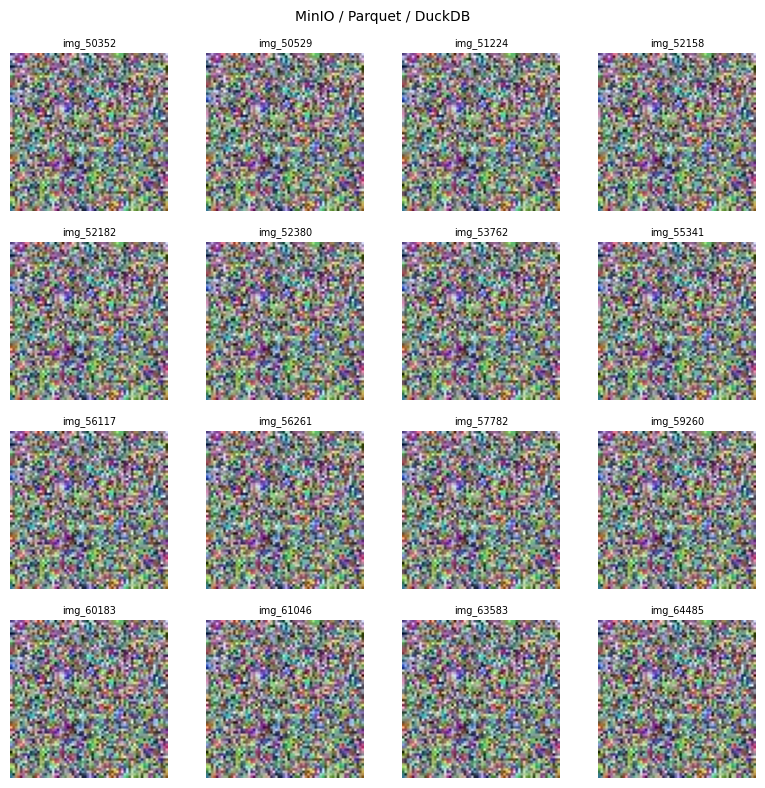

In [8]:
import matplotlib.pyplot as plt

N_PLOT  = 16
sample  = result[:N_PLOT]

cols = 4
rows = (N_PLOT + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2))
axes = np.array(axes).flatten()

for ax, (img_id, jpeg_bytes) in zip(axes, sample):
    arr = np.array(Image.open(io.BytesIO(bytes(jpeg_bytes))))
    ax.imshow(arr)
    ax.set_title(f'img_{img_id}', fontsize=7)
    ax.axis('off')

for ax in axes[N_PLOT:]:
    ax.set_visible(False)

plt.suptitle('MinIO / Parquet / DuckDB', fontsize=10)
plt.tight_layout()
plt.show()